# S&P 500 Model Comparison Analysis

Comparing three models trained to predict S&P 500 returns using macroeconomic features:
- **Random Forest** — ensemble of decision trees

- **Ridge Regression** — linear model with L2 regularisation
- **XGBoost** — gradient boosted trees

All models use the same 7 differenced/lagged features:
`CPI_Change_lag1`, `Rate_Change`, `GDP_Growth_lag2`, `Unemp_Change_lag1`, `USD_Change`, `VIX_Change`, `Credit_Spread_lag2`

**Train set:** 346 samples | **Test set:** 69 samples

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
base_dir = Path().resolve().parent
sys.path.append(str(base_dir))
MODEL_DIR = str(base_dir / "models")

## Load all saved results
Every training notebook saved its outputs using the same `save_evaluation()`, `save_shap()`, and `save_model()` functions — so the structure is consistent across all three models.

In [2]:
from utils.load_results import load_evaluations, load_shap_values, load_models, get_y_test

# load saved results, shap values, and models
results   = load_evaluations(MODEL_DIR)
shap_data = load_shap_values(MODEL_DIR)
models    = load_models(MODEL_DIR)
models_obj = load_models(MODEL_DIR)
y_test    = get_y_test(results)

Loaded 3 evaluations: ['rf', 'ridge', 'xgboost']
Loaded 3 SHAP files: ['rf', 'ridge', 'xgboost']
Loaded 3 models: ['rf', 'ridge', 'xgboost']
Loaded 3 models: ['rf', 'ridge', 'xgboost']


## Which model fits best?
A quick summary of all metrics before we look at any charts. This is the executive summary, this table tells the full story.

In [3]:
from src.metrics_table import print_metrics_table
print_metrics_table(results)

Model             R² Train    R² Test   RMSE Train    RMSE Test  MAE Train   MAE Test  Dir Train   Dir Test
rf                  0.4795     0.3220        2.944        4.132      2.207      3.227      78.90      73.91
ridge               0.3666     0.3240        3.248        4.126      2.468      3.166      74.86      73.91
xgboost             0.5131     0.3464        2.848        4.057      2.131      3.192      79.48      71.01


#### Key findings
- **XGBoost has the best test R²** (0.3464)
- **Ridge is the most consistent** — smallest gap between train and test (0.366 → 0.324)
- **RF falls between the two** — moderate train performance

- All three models achieve **71–74% directional accuracy** on the test set, meaning they predict the correct sign of S&P 500 movement about 3 out of 4 times
- All test R² values are below 0.35 — these are modest fits, typical for financial return prediction

## How do they compare visually?
Numbers can be deceiving. Side-by-side bars make the train vs test gap immediately obvious.if one model has a tall train bar but a short test bar, it's memorising noise rather than learning patterns.

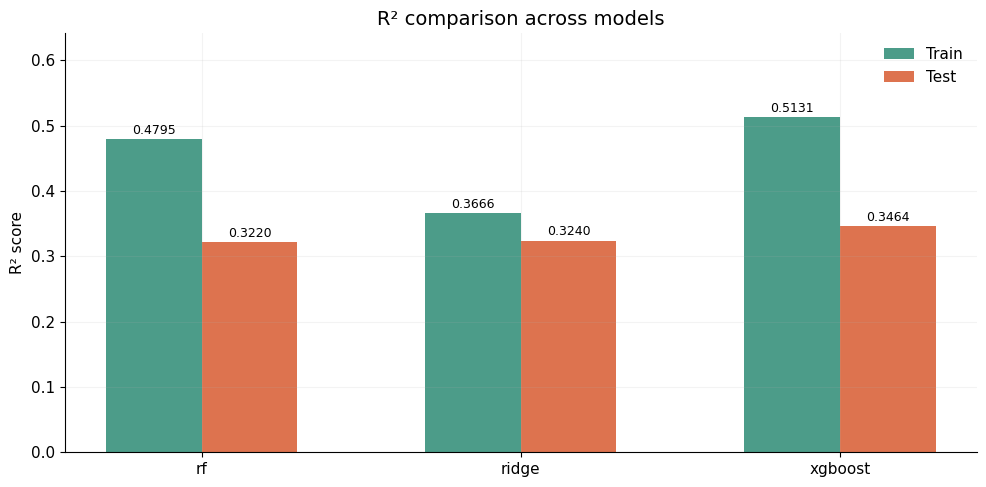

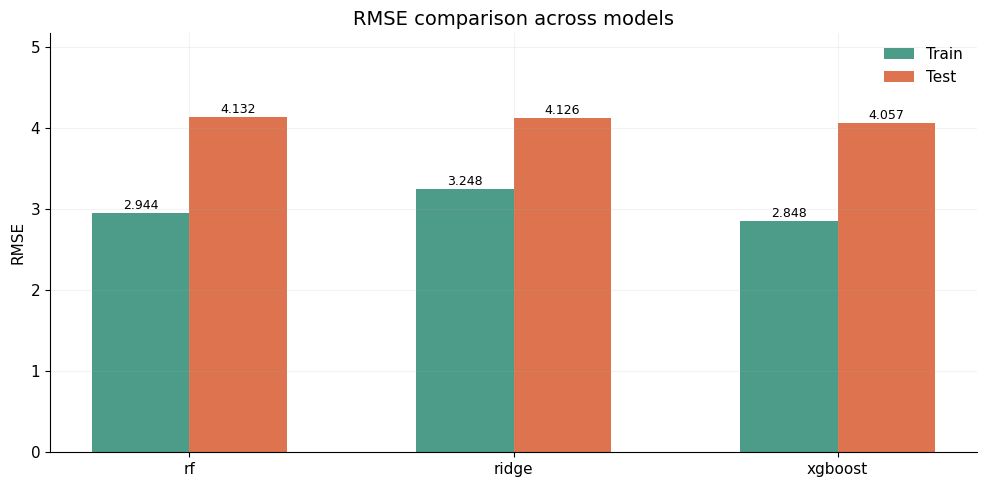

In [4]:
from src.compare_r2_rmse import compare_r2, compare_rmse
compare_r2(results)
compare_rmse(results)

## Are any models memorising noise?
The heatmap quantifies exactly how much each model degrades from train to test. Higher values (darker colors) mean more overfitting. This tells us whether the accuracy numbers from previos step can be trusted.

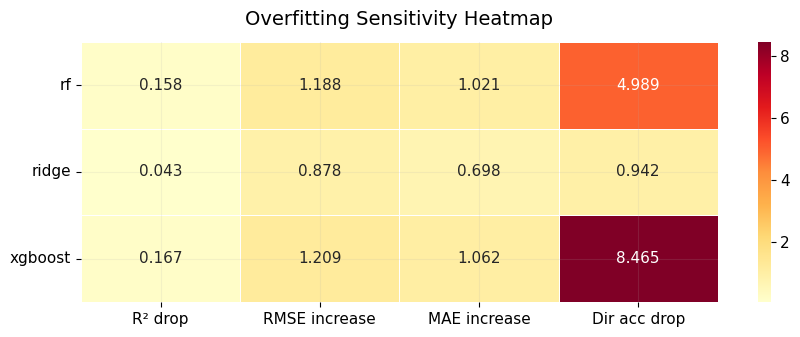

In [5]:
from src.compare_overfitting import compare_overfitting
compare_overfitting(results)

#### Key findings
- **RF and XGBoost both overfit than Ridge** — RF's R² drops by 0.16, XGBoost by 0.17. Both tree-based models memorise training patterns than ridge

- **Ridge is the most stable** — R² drops only 0.04, nearly identical on train and test.
- **RMSE tells the same story**: Ridge's RMSE increases least (0.88), while RF and XGBoost both increase by ~1.2
- **Despite overfitting, XGBoost still wins on test** — it has the best test R² (0.346)


## What are they actually predicting, and where do they fail?

Instead of comparing raw predictions (which often overlap and are hard to read), focus on **residuals**.

**Residuals** are the difference between:
- what the model predicted  
- what actually happened  

Analysing residuals helps to:

- detect **systematic bias** (consistent over- or under-prediction)  
- identify **patterns in errors** across different conditions  
- understand **tail risk** (large or extreme errors) that summary metrics may hide  

This gives a clearer and more reliable view of model performance.
 Residuals reveal systematic biases, inconsistent error patterns, and tail-risk behaviour that summary metrics hide.

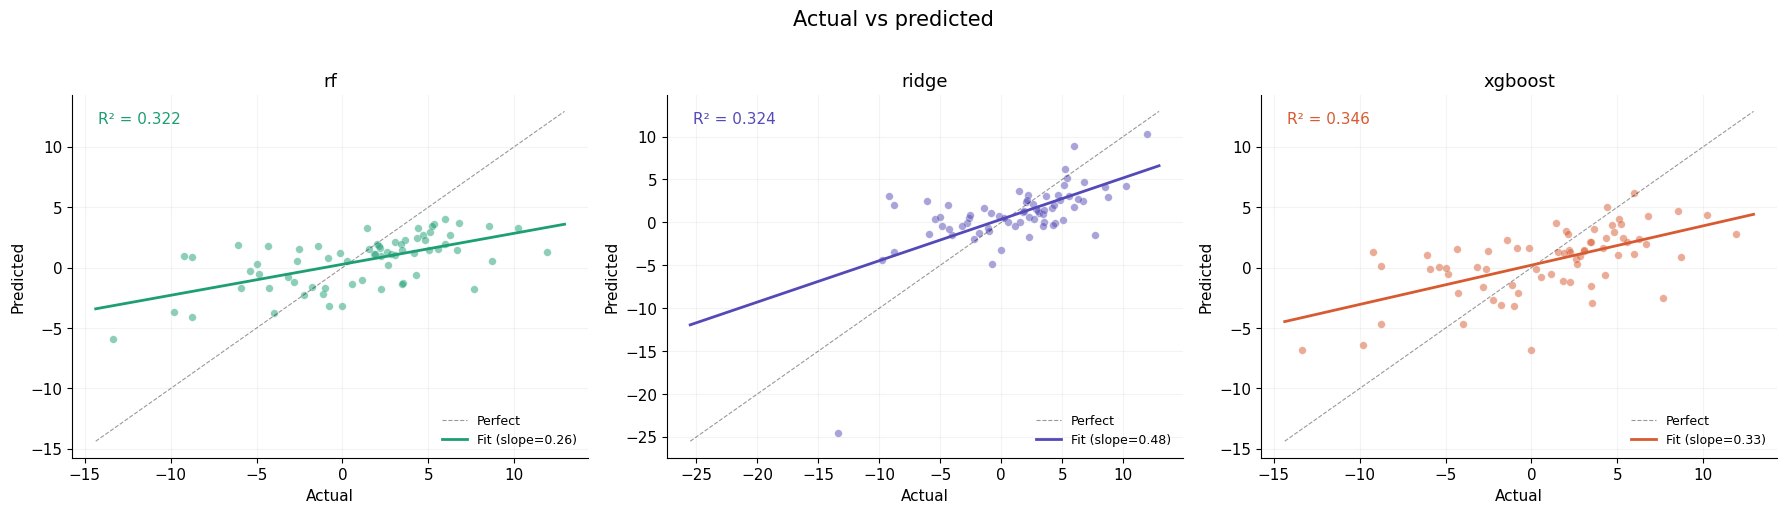

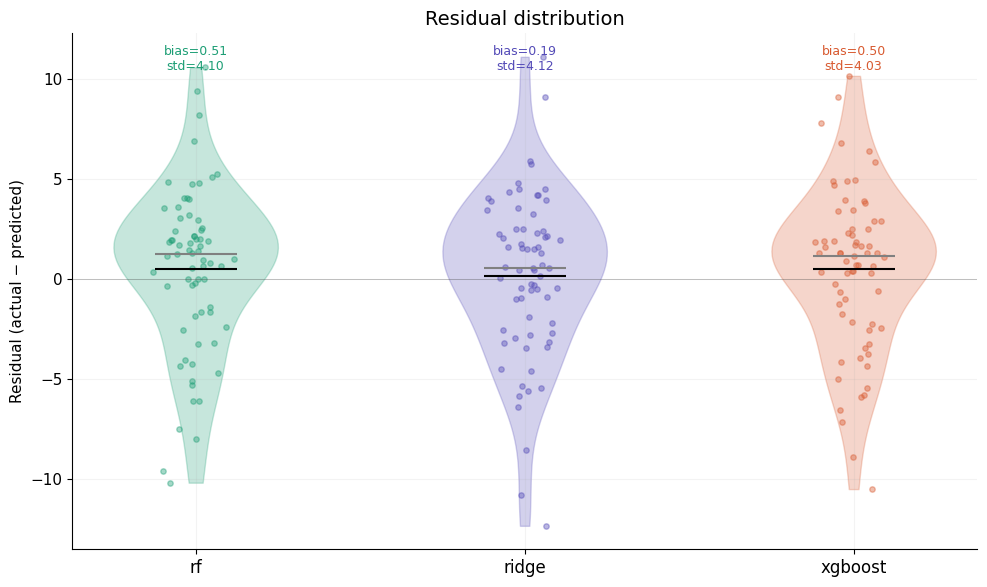

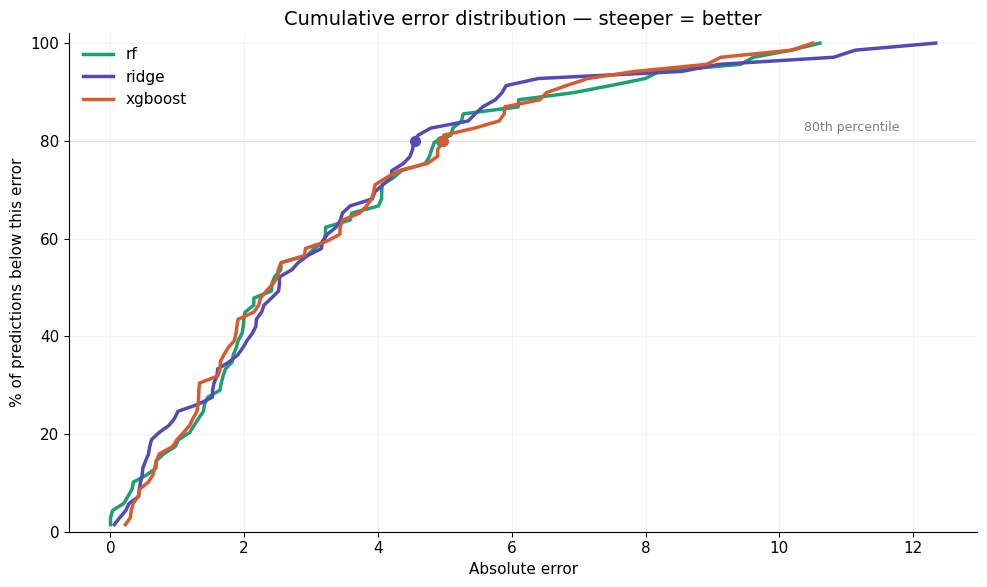

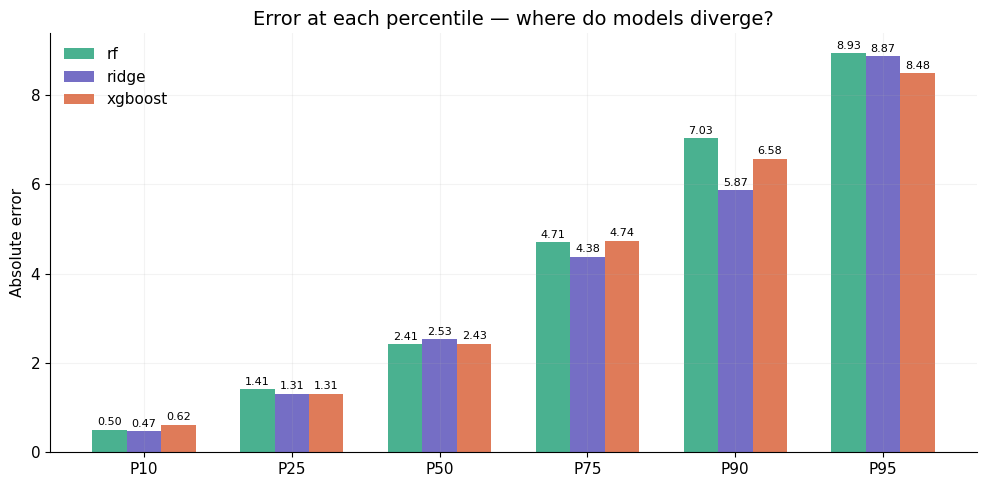


Model               Bias      Std     Skew  P50 err  P80 err  P95 err
rf                 0.506    4.101   -0.373    2.415    4.941    8.934
ridge              0.186    4.122   -0.476    2.526    4.559    8.873
xgboost            0.504    4.026   -0.293    2.428    4.976    8.485


In [6]:
from src.prediction import compare_predictions
compare_predictions(results, y_test)

#### Key findings
- **All three models have positive bias** — they slightly overpredict S&P 500 returns (RF bias: +0.5, Ridge: +0.19, XGBoost: +0.5)

- **Ridge has the lowest bias** but similar error spread to the others
- **Cumulative error curves** are nearly overlapping — at the 80th percentile, all models have nearly 4.5–5.0 absolute error
- **Tail risk is similar** — P95 errors range from 8.4 to 9 across models, meaning 1 in 20 predictions is off by ~9 percentage points
- The violin plots show all models have **left-skewed residuals** (negative skew), meaning occasional large underpredictions

## Which features matter, and do models agree?
SHAP values provide a unified importance measure that works across all model types — unlike raw feature importance which uses different units (impurity, coefficients, gain). The radar chart and rank table reveal whether the three architectures agree on which macro features drive S&P 500 predictions.

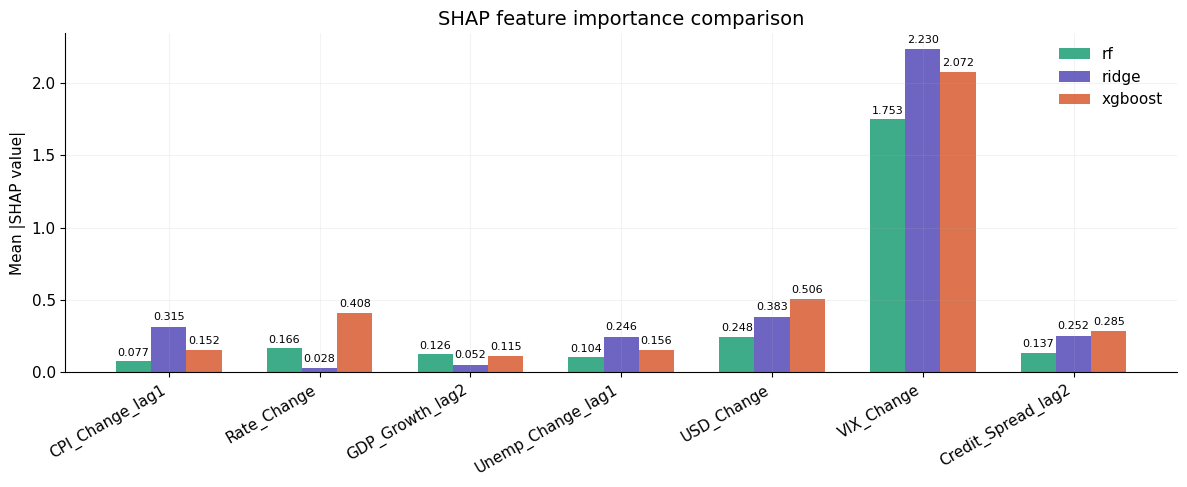

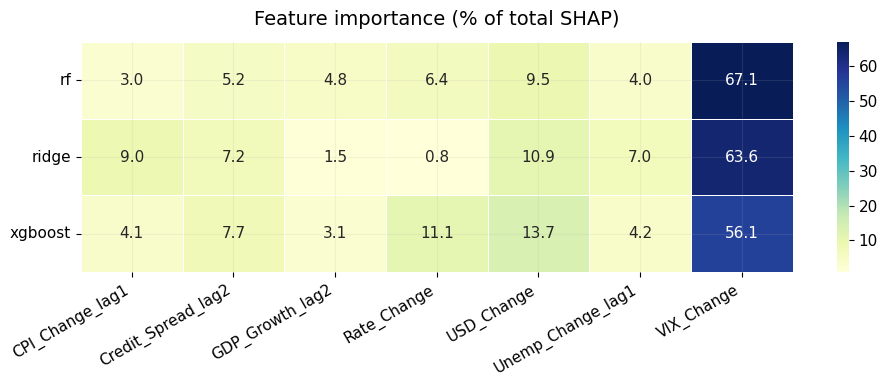

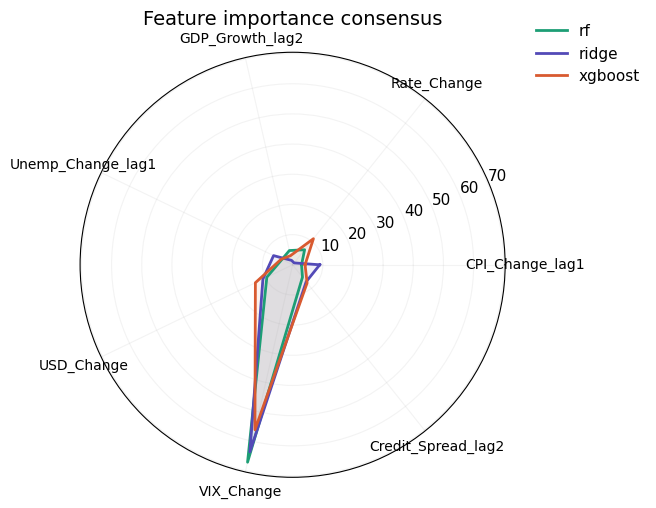


Feature ranking by SHAP (1 = most important)
                    rf  ridge  xgboost  Avg rank
VIX_Change           1      1        1       1.0
USD_Change           2      2        2       2.0
Credit_Spread_lag2   4      4        4       4.0
Rate_Change          3      7        3       4.3
CPI_Change_lag1      7      3        6       5.3
Unemp_Change_lag1    6      5        5       5.3
GDP_Growth_lag2      5      6        7       6.0



In [7]:
from src.compare_feature_importance import compare_feature_importance
compare_feature_importance(shap_data)

#### Key findings
- **VIX_Change is unanimously rank #1** across all three models — the market's fear gauge is the dominant predictor of S&P 500 returns
- **USD_Change and Credit_Spread_lag2** form a consistent second tier 

- **GDP_Growth_lag2 is consistently least important** — lagged gdp growth changes add minimal predictive value
- The radar chart shows RF and XGBoost have similar importance profiles, while Ridge distributes weight slightly more evenly
- VIX_Change SHAP value is roughly 6× larger than the next feature, showing that it has a much stronger influence than the rest.

## Are features the model learned actually useful on test data?
This is a critical diagnostic. Model importance is computed on training data. SHAP importance is computed on test data. If they agree, the feature is genuinely important. If a feature ranks high in training but low in SHAP, the model may have overfit to patterns in that feature that don't generalise.

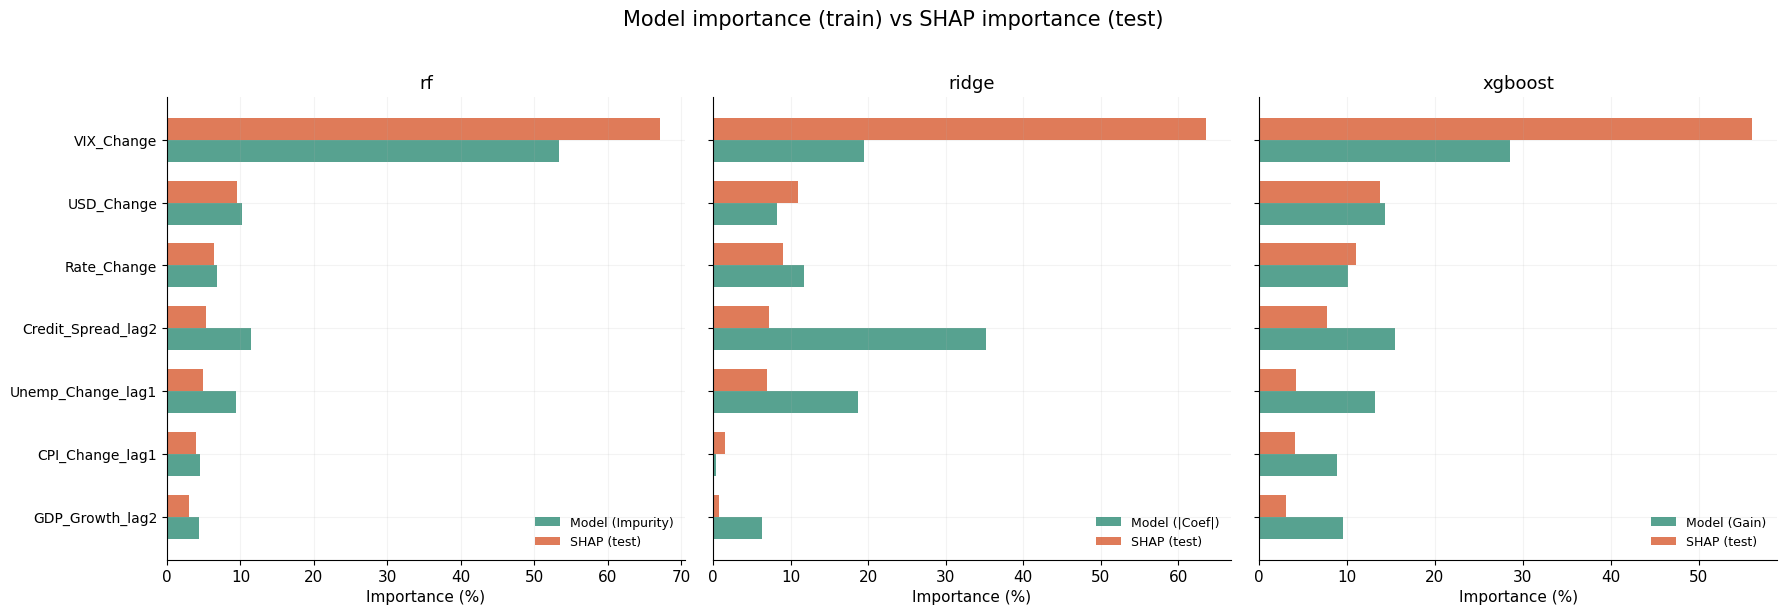

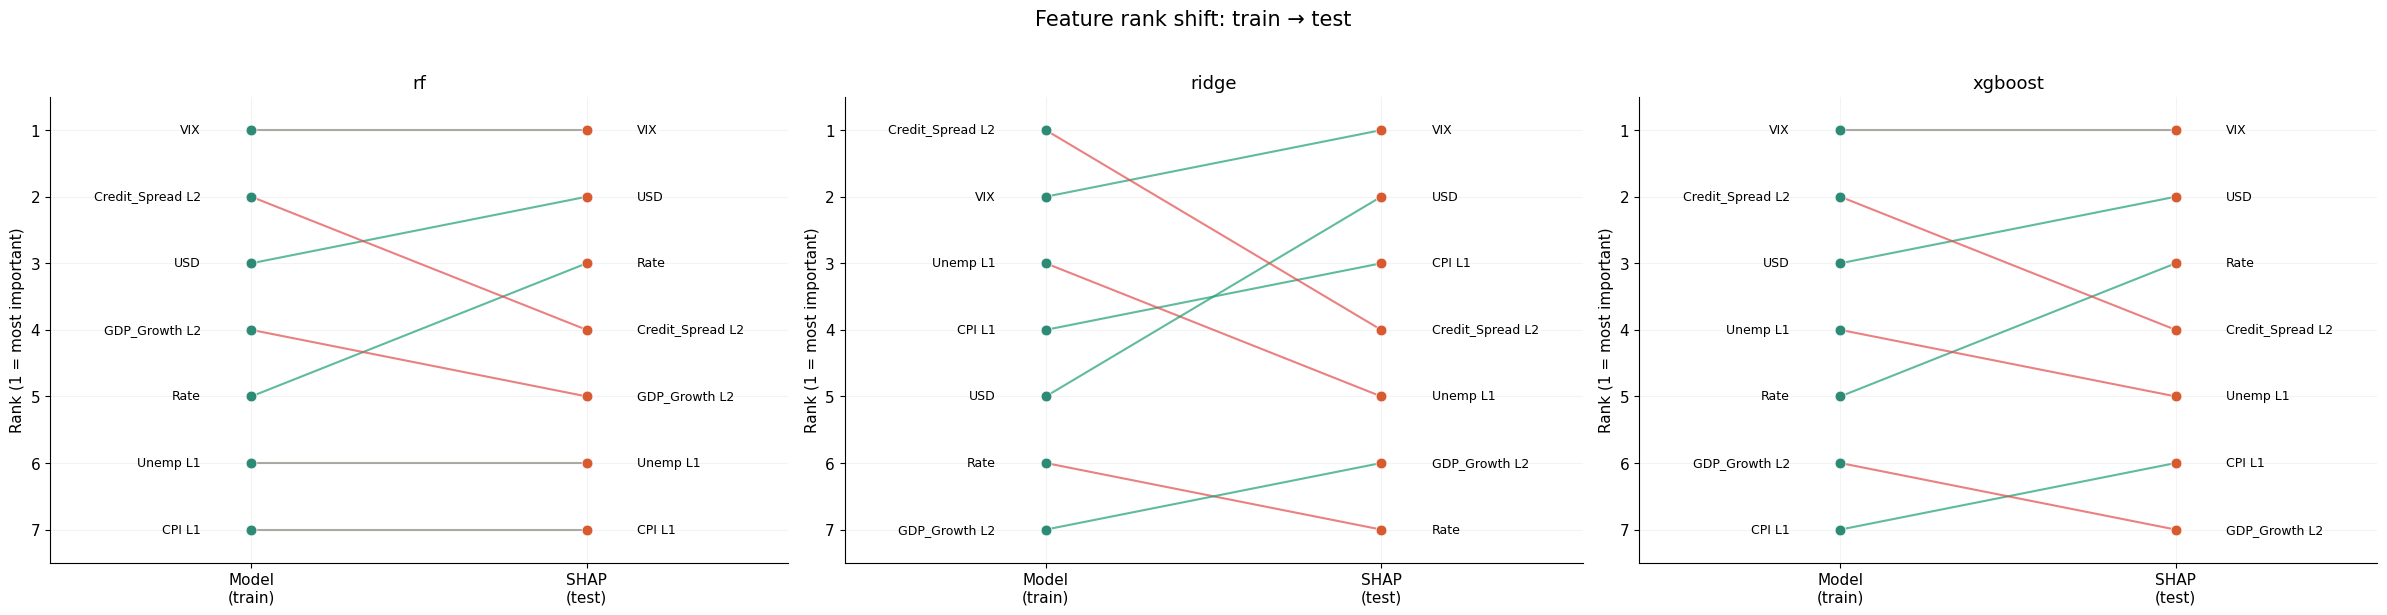


Feature importance: model (train) vs SHAP (test)

  rf (Impurity)
  Feature                    Train%  Rank   SHAP%  Rank  Shift   Flag
  --------------------------------------------------------------
  CPI_Change_lag1              4.3%    7    3.0%    7    +0       
  Rate_Change                  6.8%    5    6.4%    3    +2       
  GDP_Growth_lag2              9.4%    4    4.8%    5    -1       
  Unemp_Change_lag1            4.4%    6    4.0%    6    +0       
  USD_Change                  10.3%    3    9.5%    2    +1       
  VIX_Change                  53.3%    1   67.1%    1    +0       
  Credit_Spread_lag2          11.4%    2    5.2%    4    -2  CHECK

  ridge (|Coef|)
  Feature                    Train%  Rank   SHAP%  Rank  Shift   Flag
  --------------------------------------------------------------
  CPI_Change_lag1             11.7%    4    9.0%    3    +1       
  Rate_Change                  6.3%    6    0.8%    7    -1       
  GDP_Growth_lag2              0.4%    7  

In [8]:
from src.compare_importance_vs_shap import compare_importance_vs_shap
compare_importance_vs_shap(shap_data, models_obj)
 

## Do models agree on individual predictions?
High correlation between two models means they're making similar predictions — ensembling them won't add much value. Low correlation means the models capture different patterns, and combining them could improve overall performance.

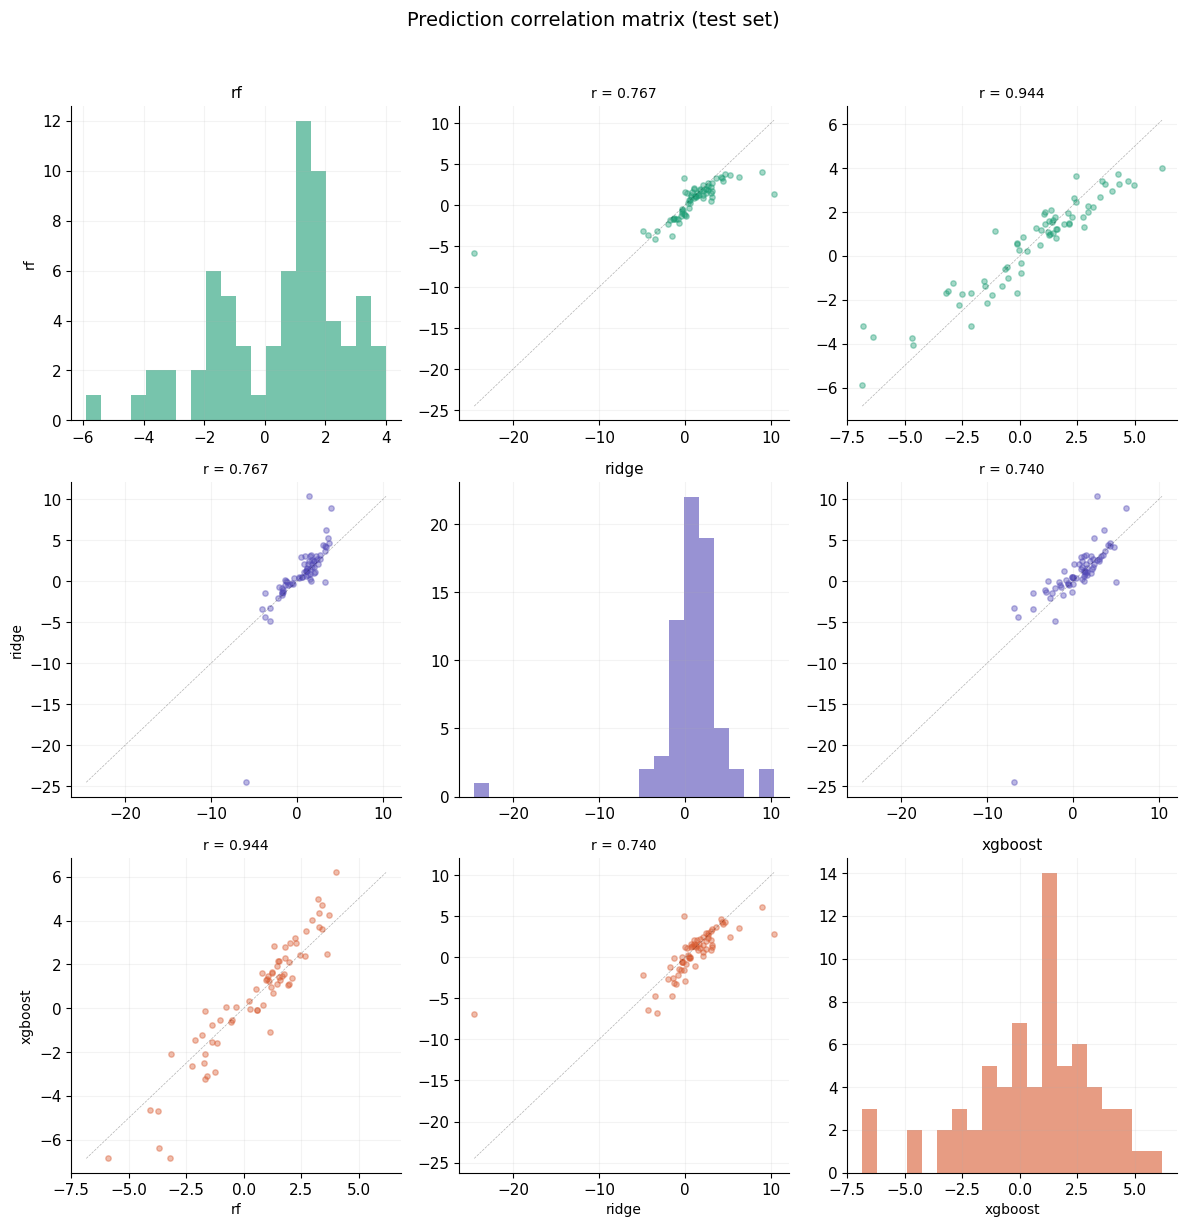


Prediction correlation (test set)
                         rf       ridge     xgboost
             rf       1.000       0.767       0.944
          ridge       0.767       1.000       0.740
        xgboost       0.944       0.740       1.000


In [9]:
from src.compare_prediction_correlation import compare_prediction_correlation
compare_prediction_correlation(results)

#### Key findings
- **RF and XGBoost are nearly identical** (r = 0.95) — both are tree-based models learning similar splits, so ensembling them provides minimal benefit
- **Ridge is genuinely different** (r = 0.77 with RF, r = 0.74 with XGBoost) — its linear structure captures different patterns

- **Ensembling models**: a weighted average of RF + Ridge (or XGBoost + Ridge) could improve predictions, since they make different errors on different samples
- The diagonal histograms confirm Ridge has a tighter, more concentrated prediction distribution compared to the tree-based models

## The Verdict

Combine all the evidence below to form overall view:

- accuracy metrics  
- overfitting behaviour  
- residual analysis  
- feature importance agreement  
- prediction correlation  

This helps to understand how the models behave from different angles, not just a single metric.

In [10]:
from src.final_verdict import print_final_verdict
print_final_verdict(results, shap_data)


                     FINAL MODEL COMPARISON                      

  Criterion                      Winner          Value          
  -------------------------------------------------------
  Best test R²                   xgboost         0.3464         
  Best test RMSE                 xgboost         4.057          
  Best test MAE                  ridge           3.166          
  Best direction accuracy        rf              73.91%         
  Least overfitting              ridge                          

  Model           Top SHAP feature          SHAP value  
  --------------------------------------------------
  rf              VIX_Change                1.7527      
  ridge           VIX_Change                2.2302      
  xgboost         VIX_Change                2.0725      

  Model             Wins
  ----------------------
  rf                 1  █
  ridge              2  ██
  xgboost            2  ██

  Recommendation: ridge (2/5 criteria)


### Summary

| Evidence | Winner | Insight |
|----------|--------|---------|
| Test accuracy (R², RMSE) | XGBoost | Marginally best, but all models are close |
| Direction accuracy | RF | 73.9% — gets the sign right 3 out of 4 times |
| Overfitting resistance | Ridge | Most stable train→test, most trustworthy |
| Feature consensus | All agree | VIX is #1, pushes S&P DOWN. GDP pushes UP. |
| Train vs test importance | All flagged | VIX is over-relied upon during training |
| Ensemble potential | XGBoost + Ridge | Different architectures capture different patterns |

### Future works
1. **Ridge is the primary model** — best test performance across 2 of 5 criteria
2. **Need to consider XGBoost + Ridge ensemble** — their low correlation suggests blending could reduce variance
3. **VIX dominance is real but risky** — 60-69% concentration on one feature means model performance depends heavily on VIX being predictive in future regimes
4. **Need to consider adding features** — the remaining 6 features contribute only 30-37% combined. Additional macro signals (yield curve slope, earnings momentum, sentiment) could reduce VIX dependency

5. **Increace test samples size** — validate with walk-forward cross-validation